# Fundamentos de Clustering y K-Means

Hasta ahora trabajamos con **aprendizaje supervisado**: cada fila del dataset
tenía una respuesta correcta (`y`) y el modelo aprendía a predecirla.

Iniciamos **aprendizaje no supervisado**: los datos **no traen
ninguna etiqueta**. El objetivo ya no es predecir un valor conocido, sino
**descubrir estructura** — encontrar grupos de observaciones parecidas entre
sí sin que nadie le diga al algoritmo cuáles son esos grupos de antemano.

A ese proceso de encontrar grupos se le llama **clustering**, y cada grupo
encontrado es un **cluster**. En esta clase veremos el algoritmo más usado
para esto: **K-Means**.

Contenido de hoy:
1. Intuición de K-Means con un ejemplo mínimo de 2 variables
2. Centroides e inercia
3. El método del codo para elegir `k`
4. Por qué escalar los datos antes de aplicar clustering
5. Un ejemplo con varias variables (igual que en un caso real) + PCA para visualizar

In [2]:
%pip install numpy pandas matplotlib scikit-learn


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster        import KMeans
from sklearn.preprocessing  import StandardScaler
from sklearn.decomposition  import PCA
from sklearn.impute         import SimpleImputer

plt.style.use("seaborn-v0_8-whitegrid")
SEED = 42

---
## 1. Intuición de K-Means: clasificación de estrellas

Vamos a usar un dataset mínimo y armado a mano: 20 estrellas descritas por
solo dos variables, **temperatura superficial** (en miles de Kelvin) y
**luminosidad** (relativa al Sol). Los 20 puntos fueron elegidos a propósito
para formar tres grupos visualmente claros, de forma que podamos verificar
"a ojo" si el algoritmo encuentra lo mismo que nosotros veríamos.

Nadie le va a decir al modelo que existen tres tipos de estrella — eso es
justamente lo que K-Means debe descubrir solo.

Forma del arreglo: (20, 2)  (20 estrellas, 2 variables)


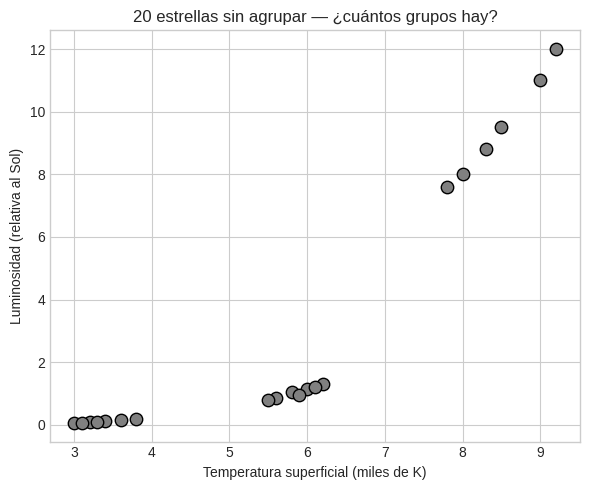

In [4]:
# 20 estrellas elegidas a mano: 7 "frías y tenues", 7 "tipo solar", 6 "calientes y muy luminosas".
datos_estrellas = [
    # temperatura (miles de K), luminosidad (relativa al Sol)
    (3.2, 0.08), (3.4, 0.12), (3.0, 0.06), (3.6, 0.15), (3.3, 0.10), (3.8, 0.18), (3.1, 0.07),
    (5.6, 0.85), (5.8, 1.05), (6.0, 1.15), (5.5, 0.78), (6.2, 1.30), (5.9, 0.95), (6.1, 1.20),
    (8.0, 8.0),  (8.5, 9.5),  (9.0, 11.0), (7.8, 7.6),  (9.2, 12.0), (8.3, 8.8),
]

X_estrellas = np.array(datos_estrellas)
print(f"Forma del arreglo: {X_estrellas.shape}  (20 estrellas, 2 variables)")

# Antes de aplicar cualquier algoritmo: ¿cuántos grupos ves a simple vista?
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_estrellas[:, 0], X_estrellas[:, 1], s=80, color="gray", edgecolor="black")
ax.set_xlabel("Temperatura superficial (miles de K)")
ax.set_ylabel("Luminosidad (relativa al Sol)")
ax.set_title("20 estrellas sin agrupar — ¿cuántos grupos hay?")
plt.tight_layout()
plt.show()

---
## 2. Centroides e inercia

K-Means funciona repitiendo dos pasos hasta que el resultado deja de cambiar:

1. **Asignación**: cada punto se asigna al centroide más cercano.
2. **Actualización**: cada centroide se recalcula como el promedio de los
   puntos que le fueron asignados.

El usuario debe decidir de antemano **cuántos centroides** quiere — ese es
el parámetro `k`. La **inercia** mide qué tan compactos quedaron los grupos:
es la suma de las distancias al cuadrado entre cada punto y su centroide.
A menor inercia, más juntos están los puntos de cada cluster (pero ojo:
la inercia siempre baja si `k` sube, así que no sirve para elegir `k` por
sí sola sin un criterio adicional — eso lo vemos en la sección 3).

La siguiente función entrena K-Means con el `k` que le indiquemos y grafica,
en una sola imagen: los puntos coloreados por cluster, los centroides
marcados con una X roja, y el valor de inercia en el título.

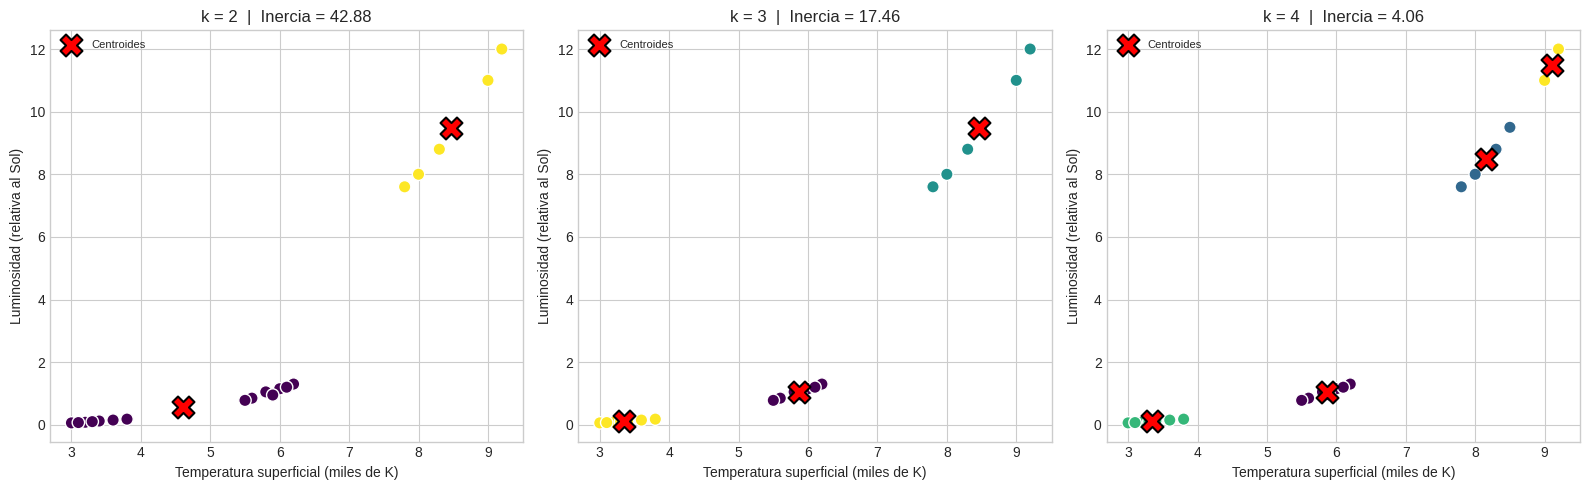

In [5]:
def entrenar_y_graficar_kmeans(X, k, ax, etiquetas_ejes=("Variable 1", "Variable 2")):
    """Entrena KMeans con k clusters sobre X y grafica puntos + centroides + inercia."""
    modelo = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    etiquetas = modelo.fit_predict(X)

    ax.scatter(X[:, 0], X[:, 1], c=etiquetas, cmap="viridis",
               s=80, edgecolor="white", zorder=2)
    ax.scatter(modelo.cluster_centers_[:, 0], modelo.cluster_centers_[:, 1],
               c="red", marker="X", s=250, edgecolor="black",
               linewidth=1.5, zorder=3, label="Centroides")
    ax.set_title(f"k = {k}  |  Inercia = {modelo.inertia_:.2f}")
    ax.set_xlabel(etiquetas_ejes[0])
    ax.set_ylabel(etiquetas_ejes[1])
    ax.legend(loc="upper left", fontsize=8)
    return modelo


# Comparamos el mismo dataset con distintos valores de k, una gráfica por cada uno.
ejes_estrellas = ("Temperatura superficial (miles de K)", "Luminosidad (relativa al Sol)")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, k in zip(axes, [2, 3, 4]):
    entrenar_y_graficar_kmeans(X_estrellas, k, ax, ejes_estrellas)
plt.tight_layout()
plt.show()

# Con k=3 cada cluster corresponde a un tipo de estrella claramente distinto.
# Con k=2 se mezclan dos tipos en un mismo grupo; con k=4 se divide un tipo
# real en dos clusters artificiales. Cambiar k cambia tanto la forma de los
# grupos como el valor de inercia — entre más alto k, menor la inercia.

---
## 3. Método del Codo: ¿cómo elegir `k`?

Como la inercia siempre disminuye al aumentar `k` (en el caso extremo,
`k = número de puntos` da inercia 0, un cluster por punto, lo cual no sirve
de nada), no podemos elegir `k` buscando la menor inercia posible.

En su lugar, graficamos la inercia para varios valores de `k` y buscamos el
punto donde la curva deja de bajar de forma pronunciada y se "aplana" — a
eso se le llama el **codo** de la curva. Después de ese punto, agregar más
clusters ya no mejora mucho la compactación, solo añade complejidad.

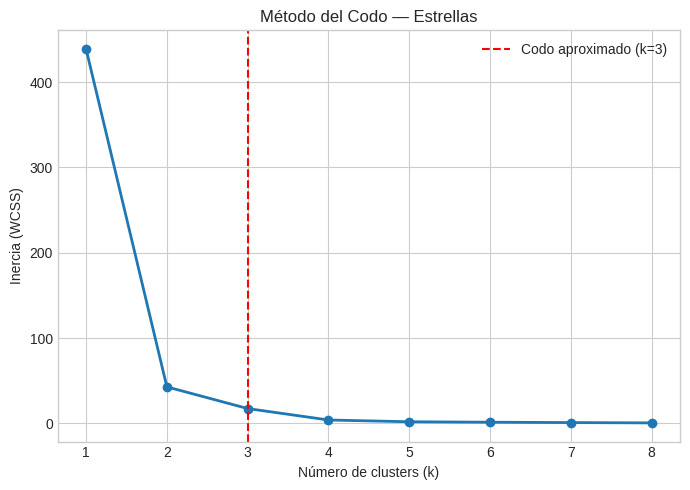

In [6]:
inercias = []
rango_k = range(1, 9)
for k in rango_k:
    modelo_k = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_estrellas)
    inercias.append(modelo_k.inertia_)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(list(rango_k), inercias, marker="o", linewidth=2)
ax.axvline(x=3, color="red", linestyle="--", label="Codo aproximado (k=3)")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Inercia (WCSS)")
ax.set_title("Método del Codo — Estrellas")
ax.legend()
plt.tight_layout()
plt.show()

# La caída de inercia es muy pronunciada de k=1 a k=3, y se aplana después de
# k=3 — coincide con los tres tipos de estrella que diseñamos en el dataset.
# El método del codo es una guía visual, no una fórmula exacta: distintas
# personas podrían marcar el codo en k=3 o k=4 según qué tan pronunciado
# vean el cambio de pendiente. Por eso en la práctica se combina con otras
# métricas de evaluación (las veremos en la próxima clase).

---
## 4. Por qué es indispensable escalar antes de aplicar clustering

K-Means agrupa según **distancia euclidiana**. Si una variable tiene una
escala mucho más grande que otra, esa variable dominará por completo el
cálculo de distancia, sin importar qué tan relevante sea en realidad.

El siguiente ejemplo es deliberadamente abstracto (no representa un dominio
real) para aislar el problema: `variable_1` es la que realmente separa dos
grupos; `variable_2` tiene una escala mucho mayor pero es puro ruido —no
distingue a los grupos en absoluto.

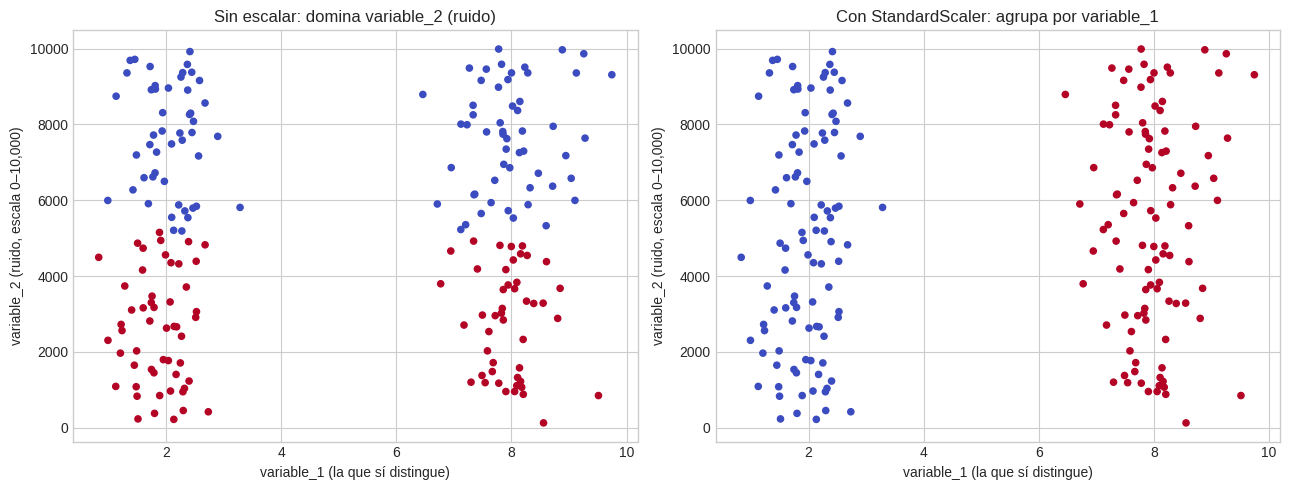

Coincidencia con el grupo real, SIN escalar : 53.0%
Coincidencia con el grupo real, CON escalado: 100.0%


In [7]:
rng = np.random.default_rng(seed=SEED)
n_por_grupo = 100

# variable_1 sí separa los grupos (rango pequeño); variable_2 es ruido con escala enorme.
grupo_a = np.column_stack([
    rng.normal(loc=2,  scale=0.6, size=n_por_grupo),
    rng.uniform(0, 10_000, size=n_por_grupo),
])
grupo_b = np.column_stack([
    rng.normal(loc=8,  scale=0.6, size=n_por_grupo),
    rng.uniform(0, 10_000, size=n_por_grupo),
])

X_escala  = np.vstack([grupo_a, grupo_b])
y_real    = np.array([0] * n_por_grupo + [1] * n_por_grupo)  # grupo real, solo para verificar

# Clustering SIN escalar: variable_2 (con rango 0-10,000) domina la distancia.
modelo_sin_escalar = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit(X_escala)

# Clustering CON escalado: ambas variables pesan por igual.
scaler          = StandardScaler()
X_escala_scaled = scaler.fit_transform(X_escala)
modelo_escalado = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit(X_escala_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X_escala[:, 0], X_escala[:, 1], c=modelo_sin_escalar.labels_, cmap="coolwarm", s=20)
axes[0].set_title("Sin escalar: domina variable_2 (ruido)")
axes[0].set_xlabel("variable_1 (la que sí distingue)")
axes[0].set_ylabel("variable_2 (ruido, escala 0–10,000)")

axes[1].scatter(X_escala[:, 0], X_escala[:, 1], c=modelo_escalado.labels_, cmap="coolwarm", s=20)
axes[1].set_title("Con StandardScaler: agrupa por variable_1")
axes[1].set_xlabel("variable_1 (la que sí distingue)")
axes[1].set_ylabel("variable_2 (ruido, escala 0–10,000)")
plt.tight_layout()
plt.show()

# Comparamos contra el grupo real (solo posible porque en este ejemplo lo construimos
# nosotros mismos; en un caso real no existiría esta columna).
coincidencias_sin_escalar = max(
    (modelo_sin_escalar.labels_ == y_real).mean(),
    (modelo_sin_escalar.labels_ != y_real).mean(),
)
coincidencias_escalado = max(
    (modelo_escalado.labels_ == y_real).mean(),
    (modelo_escalado.labels_ != y_real).mean(),
)
print(f"Coincidencia con el grupo real, SIN escalar : {coincidencias_sin_escalar:.1%}")
print(f"Coincidencia con el grupo real, CON escalado: {coincidencias_escalado:.1%}")
# StandardScaler resta la media y divide entre la desviación estándar de cada
# columna, dejando a todas las variables con media 0 y varianza 1 — así
# ninguna domina la distancia solo por tener números más grandes.

---
## 5. Ejemplo con varias variables: estaciones de monitoreo ambiental

Los casos reales casi nunca tienen solo 2 variables. Generamos un dataset
sintético de **lecturas diarias de estaciones de monitoreo ambiental**, con
seis variables numéricas. La idea es la misma que con las estrellas, solo
que ahora no podremos graficar las variables originales directamente.

In [8]:
N = 300

centros_zona = {
    "industrial":  dict(temperatura=24, humedad=45, co2=620, pm25=58, ruido=72, viento=8),
    "residencial": dict(temperatura=21, humedad=55, co2=460, pm25=28, ruido=58, viento=12),
    "natural":     dict(temperatura=18, humedad=68, co2=400, pm25=9,  ruido=38, viento=18),
}
zonas = rng.choice(list(centros_zona.keys()), size=N, p=[0.3, 0.4, 0.3])

filas = []
for zona in zonas:
    c = centros_zona[zona]
    filas.append({
        "temperatura_c"   : rng.normal(c["temperatura"], 2.0),
        "humedad_relativa": rng.normal(c["humedad"], 5.0),
        "co2_ppm"         : rng.normal(c["co2"], 35.0),
        "pm25_ugm3"       : max(0, rng.normal(c["pm25"], 6.0)),
        "ruido_db"        : rng.normal(c["ruido"], 4.0),
        "viento_kmh"      : max(0, rng.normal(c["viento"], 3.0)),
    })

df_ambiental = pd.DataFrame(filas)
print(f"Dataset generado: {df_ambiental.shape[0]} filas × {df_ambiental.shape[1]} columnas")
df_ambiental.head()

Dataset generado: 300 filas × 6 columnas


,temperatura_c,humedad_relativa,co2_ppm,pm25_ugm3,ruido_db,viento_kmh
0,23.503450,52.393385,444.760738,25.125381,61.163207,16.495123
1,20.082319,52.876131,470.992703,26.525431,61.808215,5.244668
2,22.346590,41.087918,538.787540,52.218169,68.339376,7.396686
3,20.225932,66.774697,363.921520,8.658273,42.196694,15.072124
4,22.178850,47.792745,612.246236,61.884908,71.945413,10.104991


In [9]:
# Algunos nulos para que la limpieza no quede en cero (técnica ya vista en preprocesamiento).
for col in ["co2_ppm", "pm25_ugm3"]:
    idx = rng.choice(df_ambiental.index, size=10, replace=False)
    df_ambiental.loc[idx, col] = np.nan

print("Nulos por columna:")
print(df_ambiental.isnull().sum())

Nulos por columna:
temperatura_c        0
humedad_relativa     0
co2_ppm             10
pm25_ugm3           10
ruido_db             0
viento_kmh           0
dtype: int64


### 5.1 Análisis Exploratorio de Datos (EDA)

Antes de limpiar o entrenar cualquier modelo, conviene visualizar la
distribución de cada variable y cómo se relacionan entre sí. En clustering
esto es todavía más importante que en supervisado, porque no hay una
variable objetivo que guíe el análisis: las gráficas son la única forma de
detectar outliers o variables redundantes antes de entrenar.

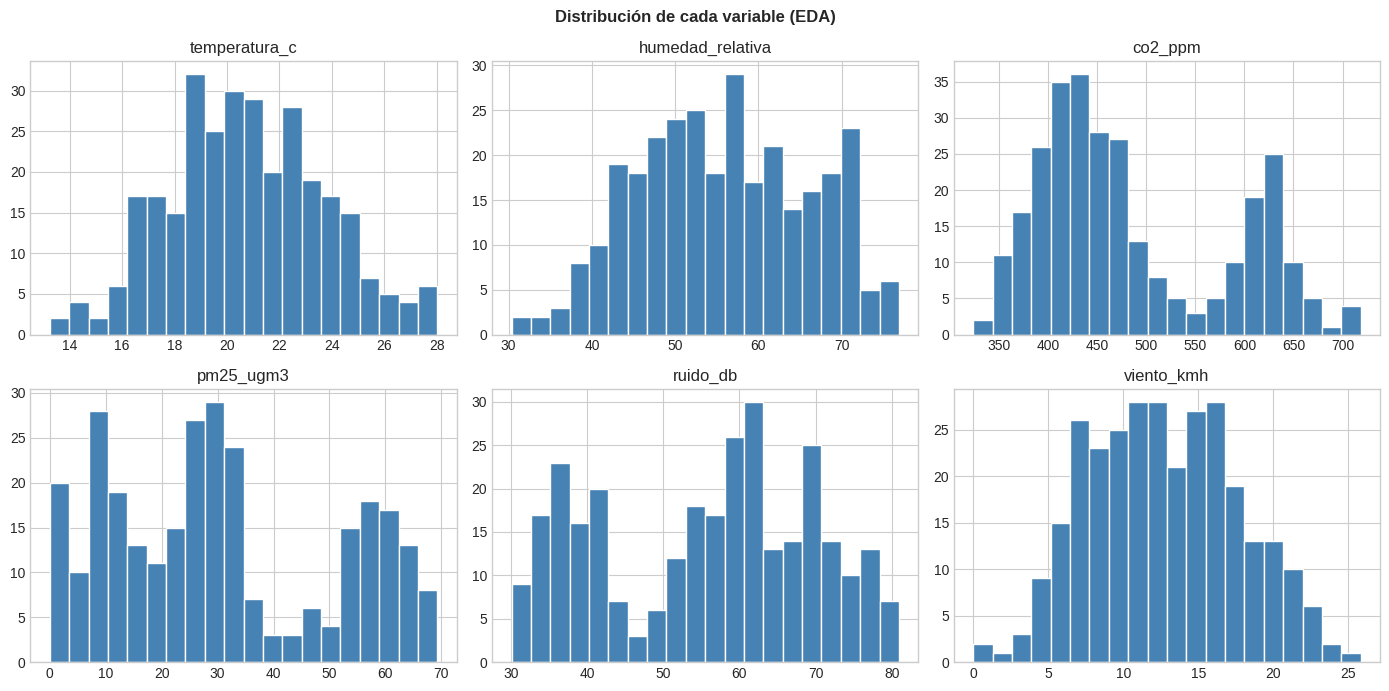

In [10]:
# Histogramas: forma de la distribución de cada variable.
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
columnas_numericas = df_ambiental.columns.tolist()
for ax, col in zip(axes.flat, columnas_numericas):
    ax.hist(df_ambiental[col].dropna(), bins=20, color="steelblue", edgecolor="white")
    ax.set_title(col)
plt.suptitle("Distribución de cada variable (EDA)", fontweight="bold")
plt.tight_layout()
plt.show()

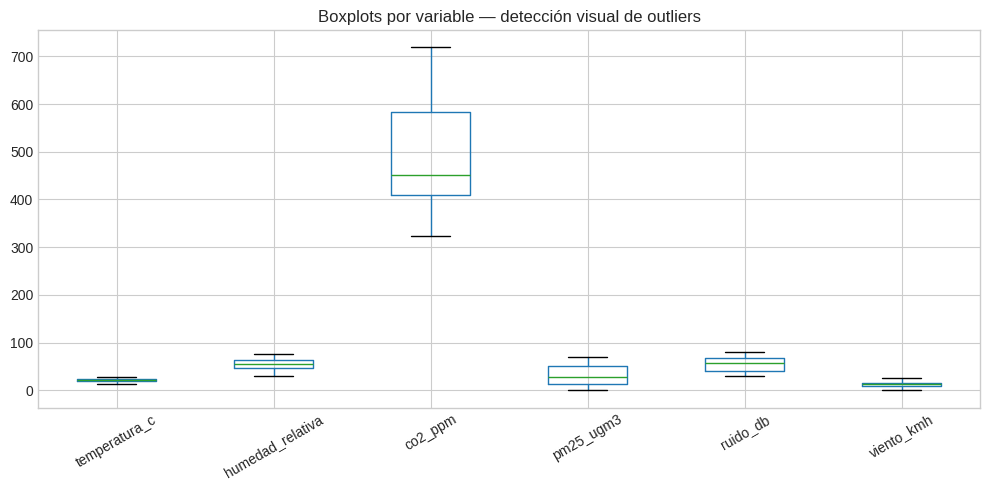

In [11]:
# Boxplots: forma rápida de detectar outliers por variable.
fig, ax = plt.subplots(figsize=(10, 5))
df_ambiental[columnas_numericas].boxplot(ax=ax, rot=30)
ax.set_title("Boxplots por variable — detección visual de outliers")
plt.tight_layout()
plt.show()

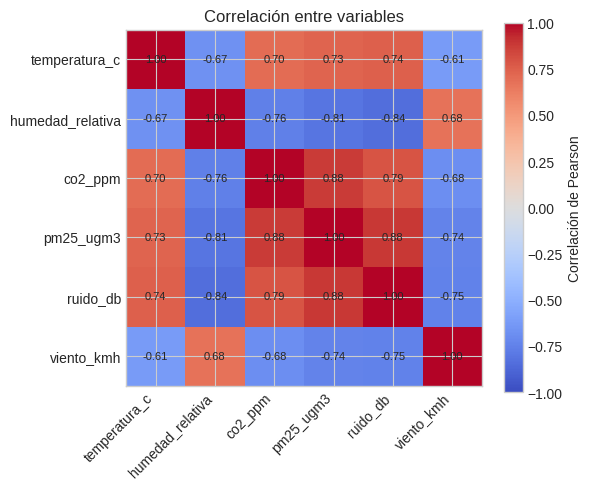

In [12]:
# Mapa de calor de correlación: variables muy correlacionadas aportan
# información redundante al cálculo de distancia (pueden "pesar doble").
corr = df_ambiental[columnas_numericas].corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="Correlación de Pearson")
ax.set_xticks(range(len(columnas_numericas)))
ax.set_yticks(range(len(columnas_numericas)))
ax.set_xticklabels(columnas_numericas, rotation=45, ha="right")
ax.set_yticklabels(columnas_numericas)
for i in range(len(columnas_numericas)):
    for j in range(len(columnas_numericas)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Correlación entre variables")
plt.tight_layout()
plt.show()

### 5.2 Limpieza, escalado y entrenamiento

Con el panorama claro gracias al EDA, ahora sí imputamos los nulos
(mediana, robusta ante outliers) y escalamos antes de entrenar.

In [13]:
imputador = SimpleImputer(strategy="median")
X_ambiental = imputador.fit_transform(df_ambiental[columnas_numericas])

scaler_ambiental  = StandardScaler()
X_ambiental_scaled = scaler_ambiental.fit_transform(X_ambiental)

print("Datos imputados y escalados:", X_ambiental_scaled.shape)
print(f"Media por columna tras escalar (debe ser ~0): {X_ambiental_scaled.mean(axis=0).round(2)}")
print(f"Desv. estándar tras escalar (debe ser ~1)   : {X_ambiental_scaled.std(axis=0).round(2)}")

Datos imputados y escalados: (300, 6)
Media por columna tras escalar (debe ser ~0): [-0.  0. -0.  0. -0. -0.]
Desv. estándar tras escalar (debe ser ~1)   : [1. 1. 1. 1. 1. 1.]


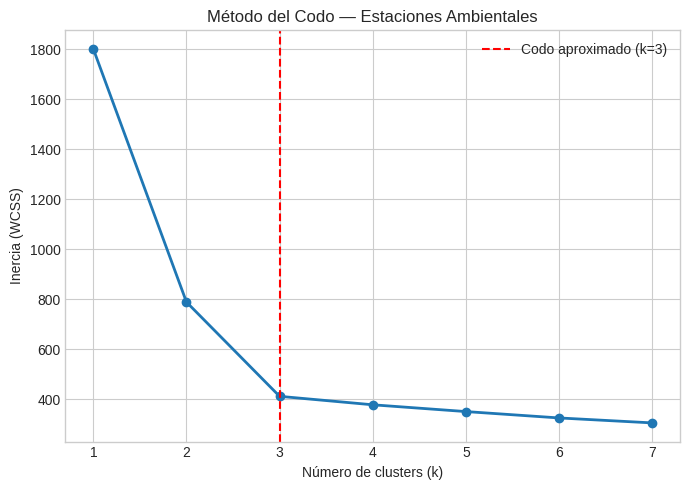

In [14]:
# Método del codo sobre este dataset, igual que en la sección 3.
inercias_amb = []
rango_k_amb  = range(1, 8)
for k in rango_k_amb:
    m = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_ambiental_scaled)
    inercias_amb.append(m.inertia_)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(list(rango_k_amb), inercias_amb, marker="o", linewidth=2)
ax.axvline(x=3, color="red", linestyle="--", label="Codo aproximado (k=3)")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Inercia (WCSS)")
ax.set_title("Método del Codo — Estaciones Ambientales")
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
K_ELEGIDO = 3
modelo_ambiental = KMeans(n_clusters=K_ELEGIDO, n_init=10, random_state=SEED)
df_ambiental["segmento"] = modelo_ambiental.fit_predict(X_ambiental_scaled)

print(f"Modelo entrenado con k={K_ELEGIDO}")
print(df_ambiental["segmento"].value_counts().sort_index())

Modelo entrenado con k=3
segmento
0     86
1     94
2    120
Name: count, dtype: int64


### 5.3 Visualización con PCA

Con seis variables ya no es posible graficar los clusters directamente.
**PCA (Análisis de Componentes Principales)** reduce las variables a un
número menor de "componentes" que conservan la mayor parte de la
variabilidad de los datos originales, sin necesitar etiquetas. Con 2
componentes ya podemos volver a graficar en un plano XY.

Varianza explicada por cada componente: [0.788 0.065]
Varianza total explicada con 2 componentes: 85.2%


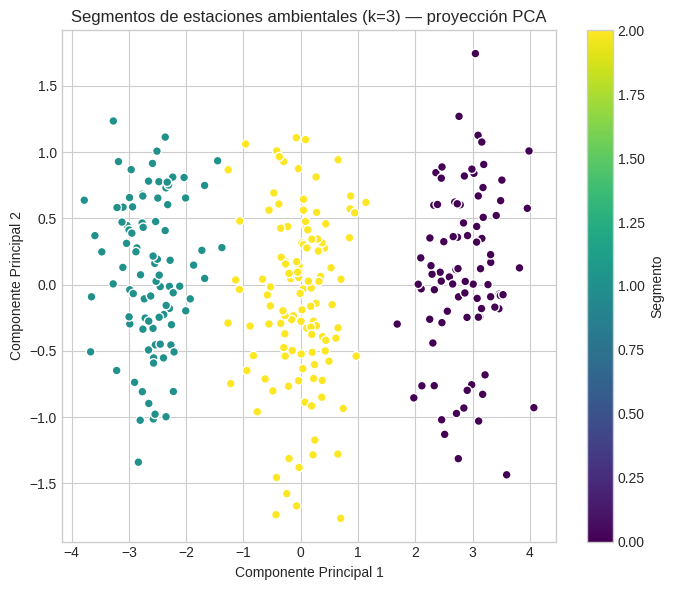

In [16]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_ambiental_scaled)

print(f"Varianza explicada por cada componente: {pca.explained_variance_ratio_.round(3)}")
print(f"Varianza total explicada con 2 componentes: {pca.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(7, 6))
dispersión = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df_ambiental["segmento"],
                         cmap="viridis", s=40, edgecolor="white")
ax.set_xlabel("Componente Principal 1")
ax.set_ylabel("Componente Principal 2")
ax.set_title(f"Segmentos de estaciones ambientales (k={K_ELEGIDO}) — proyección PCA")
plt.colorbar(dispersión, ax=ax, label="Segmento")
plt.tight_layout()
plt.show()

# Importante: los ejes del PCA ya no tienen una unidad física directa (no son
# "temperatura" ni "CO2"), son combinaciones de las variables originales. Sirven
# para visualizar la separación de los grupos, no para interpretarlos — para
# eso usamos las variables originales, como en la siguiente tabla.

In [17]:
# Perfilado básico: promedio de cada variable original por segmento.
resumen_segmentos = df_ambiental.groupby("segmento")[columnas_numericas].mean().round(1)
resumen_segmentos["cantidad_registros"] = df_ambiental["segmento"].value_counts().sort_index()
resumen_segmentos

,temperatura_c,humedad_relativa,co2_ppm,pm25_ugm3,ruido_db,viento_kmh,cantidad_registros
segmento,,,,,,,
0,23.8,44.3,621.3,57.7,71.4,7.9,86
1,17.9,67.5,400.4,9.2,37.9,18.0,94
2,20.9,55.1,452.0,27.7,58.0,12.0,120


---
## Resumen de Técnicas Cubiertas

| Técnica | Para qué sirve |
|---|---|
| `KMeans(n_clusters=k)` | Agrupar datos en k clusters según distancia euclidiana |
| `.inertia_` | Medir qué tan compactos quedaron los clusters |
| `.cluster_centers_` | Coordenadas de los centroides finales |
| Método del codo | Guía visual para elegir un valor razonable de `k` |
| `StandardScaler` | Evitar que una variable domine la distancia solo por su escala |
| `PCA(n_components=2)` | Reducir variables a 2 dimensiones para poder graficar |
| `groupby(...).mean()` | Perfilar cada cluster con las variables originales |

## Lo que se profundizará en la próxima clase

- Otros algoritmos de clustering (DBSCAN, Jerárquico) y cuándo K-Means no es
  la mejor opción.
- Métricas de validación interna (más allá del codo): Silhouette,
  Davies-Bouldin, Calinski-Harabasz.
- Cómo asignar un dato nuevo a un cluster ya entrenado.
- Persistencia del modelo entrenado.